In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# connect to your database
conn = sqlite3.connect('fraud_claims.db')

# load all three tables
claims = pd.read_sql("SELECT * FROM claims_raw", conn)
patients = pd.read_sql("SELECT * FROM patients", conn)
providers = pd.read_sql("SELECT * FROM providers", conn)

# convert data types
claims['claim_date'] = pd.to_datetime(claims['claim_date'])
claims['billed_amount'] = claims['billed_amount'].astype(float)
claims['care_hours'] = claims['care_hours'].astype(float)
claims['hourly_rate'] = claims['hourly_rate'].astype(float)

# fix is_fraud from string to boolean
claims['is_fraud'] = claims['is_fraud'].map({'True': True, 'False': False})

# fix providers boolean too
providers['is_ghost_provider'] = providers['is_ghost_provider'].map({'True': True, 'False': False})

print(f"Claims loaded   : {len(claims):,} rows")
print(f"Patients loaded : {len(patients):,} rows")
print(f"Providers loaded: {len(providers):,} rows")
print(f"\nis_fraud dtype  : {claims['is_fraud'].dtype}")
print(f"Fraud count     : {claims['is_fraud'].sum()}")
print(f"Fraud rate      : {claims['is_fraud'].mean()*100:.1f}%")

Claims loaded   : 2,000 rows
Patients loaded : 300 rows
Providers loaded: 60 rows

is_fraud dtype  : bool
Fraud count     : 300
Fraud rate      : 15.0%


## 1. Fraud vs Legitimate Claims Overview
How many of our 2,000 claims are fraudulent, and how much money is at risk?

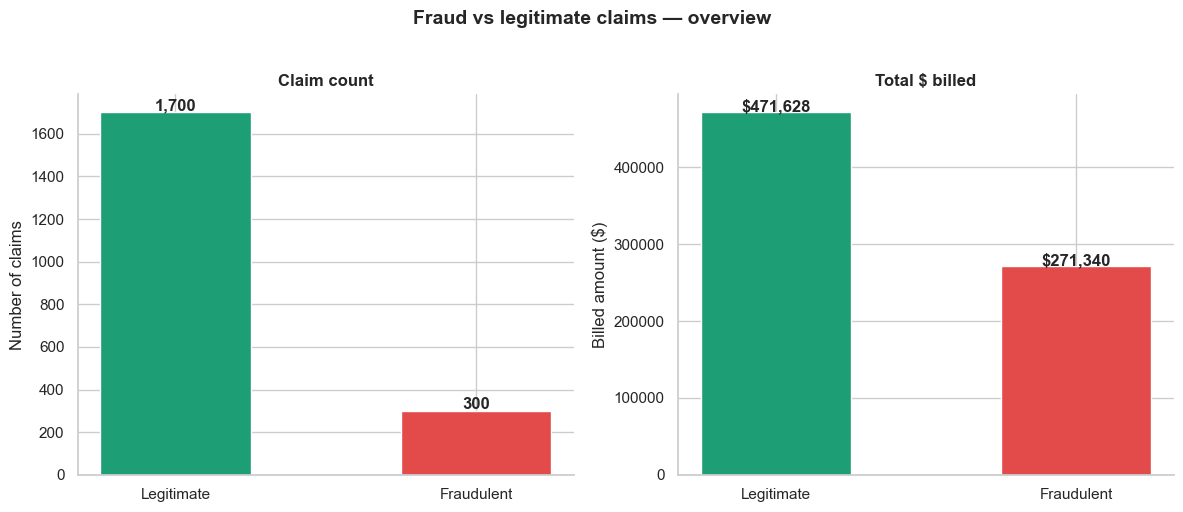

Fraud rate: 15.0%
Fraud $ at risk: $271,339.95


In [14]:
fraud_counts = claims['is_fraud'].value_counts()
fraud_labels = ['Legitimate', 'Fraudulent']
fraud_colors = ['#1D9E75', '#E24B4A']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left — count
axes[0].bar(fraud_labels, fraud_counts.values, color=fraud_colors, width=0.5)
axes[0].set_title('Claim count', fontweight='bold')
axes[0].set_ylabel('Number of claims')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')

# right — dollars
fraud_dollars = claims.groupby('is_fraud')['billed_amount'].sum()
axes[1].bar(fraud_labels, fraud_dollars.values, color=fraud_colors, width=0.5)
axes[1].set_title('Total $ billed', fontweight='bold')
axes[1].set_ylabel('Billed amount ($)')
for i, v in enumerate(fraud_dollars.values):
    axes[1].text(i, v + 1000, f'${v:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Fraud vs legitimate claims — overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart1_fraud_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fraud rate: {claims['is_fraud'].mean()*100:.1f}%")
print(f"Fraud $ at risk: ${claims[claims['is_fraud']==True]['billed_amount'].sum():,.2f}")

## 2. Fraud by Type
Which fraud type is most common and most costly?

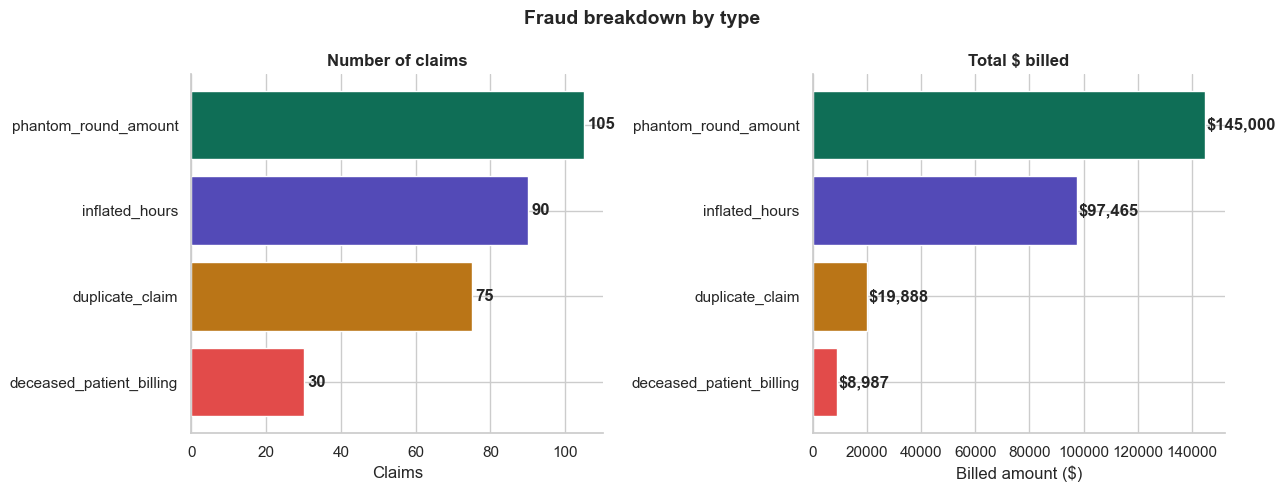

In [5]:
fraud_only = claims[claims['is_fraud'] == True]

fraud_by_type = fraud_only.groupby('fraud_type').agg(
    claim_count=('claim_id', 'count'),
    total_billed=('billed_amount', 'sum')
).reset_index().sort_values('total_billed', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#E24B4A', '#BA7517', '#534AB7', '#0F6E56']

# left — claim count
axes[0].barh(fraud_by_type['fraud_type'], fraud_by_type['claim_count'], color=colors)
axes[0].set_title('Number of claims', fontweight='bold')
axes[0].set_xlabel('Claims')
for i, v in enumerate(fraud_by_type['claim_count']):
    axes[0].text(v + 1, i, str(v), va='center', fontweight='bold')

# right — dollars
axes[1].barh(fraud_by_type['fraud_type'], fraud_by_type['total_billed'], color=colors)
axes[1].set_title('Total $ billed', fontweight='bold')
axes[1].set_xlabel('Billed amount ($)')
for i, v in enumerate(fraud_by_type['total_billed']):
    axes[1].text(v + 500, i, f'${v:,.0f}', va='center', fontweight='bold')

plt.suptitle('Fraud breakdown by type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print(claims.shape)

(2000, 13)


## 3. Fraud Rate by Provider Type
Which care setting has the highest fraud concentration?


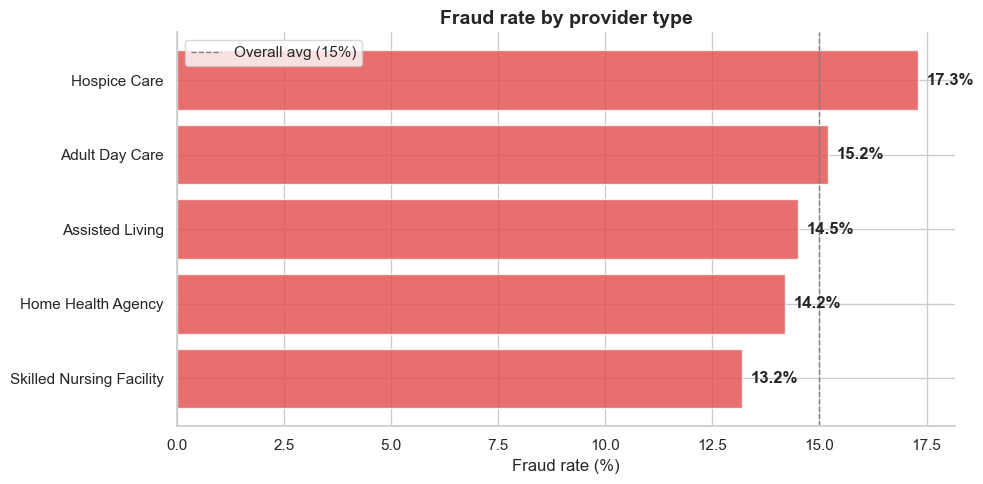

Fraud rate by provider type:
────────────────────────────────────────
Hospice Care                   17.3%  (62 fraud / 359 total)
Adult Day Care                 15.2%  (82 fraud / 538 total)
Assisted Living                14.5%  (75 fraud / 516 total)
Home Health Agency             14.2%  (51 fraud / 360 total)
Skilled Nursing Facility       13.2%  (30 fraud / 227 total)

Overall average fraud rate: 15.0%


In [18]:
merged = claims.merge(providers[['provider_id','provider_type']], on='provider_id')

fraud_by_ptype = merged.groupby('provider_type').agg(
    total_claims=('claim_id','count'),
    fraud_claims=('is_fraud','sum')
).reset_index()
fraud_by_ptype['fraud_rate'] = (fraud_by_ptype['fraud_claims'] / fraud_by_ptype['total_claims'] * 100).round(1)
fraud_by_ptype = fraud_by_ptype.sort_values('fraud_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(fraud_by_ptype['provider_type'], fraud_by_ptype['fraud_rate'], color='#E24B4A', alpha=0.8)
ax.set_xlabel('Fraud rate (%)')
ax.set_title('Fraud rate by provider type', fontsize=14, fontweight='bold')
ax.axvline(x=15, color='gray', linestyle='--', linewidth=1, label='Overall avg (15%)')
ax.legend()
for i, v in enumerate(fraud_by_ptype['fraud_rate']):
    ax.text(v + 0.2, i, f'{v}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart3_fraud_by_provider_type.png', dpi=150, bbox_inches='tight')
plt.show()

print("Fraud rate by provider type:")
print("─" * 40)
for _, row in fraud_by_ptype.sort_values('fraud_rate', ascending=False).iterrows():
    print(f"{row['provider_type']:<30} {row['fraud_rate']}%  ({int(row['fraud_claims'])} fraud / {int(row['total_claims'])} total)")
print(f"\nOverall average fraud rate: 15.0%")

## 4. Billed Amount Distribution — Fraud vs Legitimate
Do fraudulent claims look different in terms of dollar amounts?

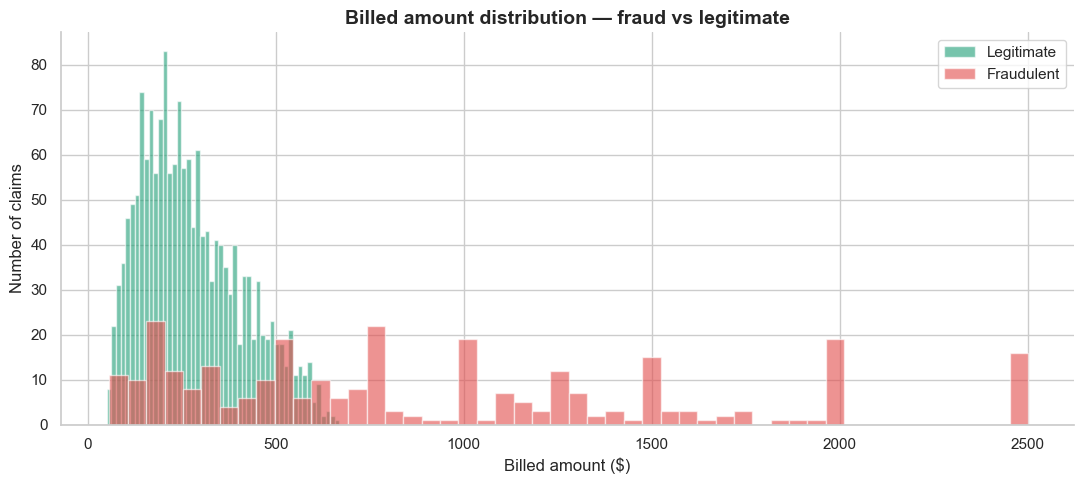

Legitimate — avg: $277.43  median: $251.56  max: $669.72
Fraudulent — avg: $904.47  median: $750.00  max: $2,500.00


In [22]:
legit = claims[claims['is_fraud']==False]['billed_amount']
fraud = claims[claims['is_fraud']==True]['billed_amount']

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(legit, bins=50, alpha=0.6, color='#1D9E75', label='Legitimate')
ax.hist(fraud, bins=50, alpha=0.6, color='#E24B4A', label='Fraudulent')
ax.set_xlabel('Billed amount ($)')
ax.set_ylabel('Number of claims')
ax.set_title('Billed amount distribution — fraud vs legitimate', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('chart4_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Legitimate — avg: ${legit.mean():,.2f}  median: ${legit.median():,.2f}  max: ${legit.max():,.2f}")
print(f"Fraudulent — avg: ${fraud.mean():,.2f}  median: ${fraud.median():,.2f}  max: ${fraud.max():,.2f}")

## 5. Monthly Fraud Trend
How does fraud volume change over time?

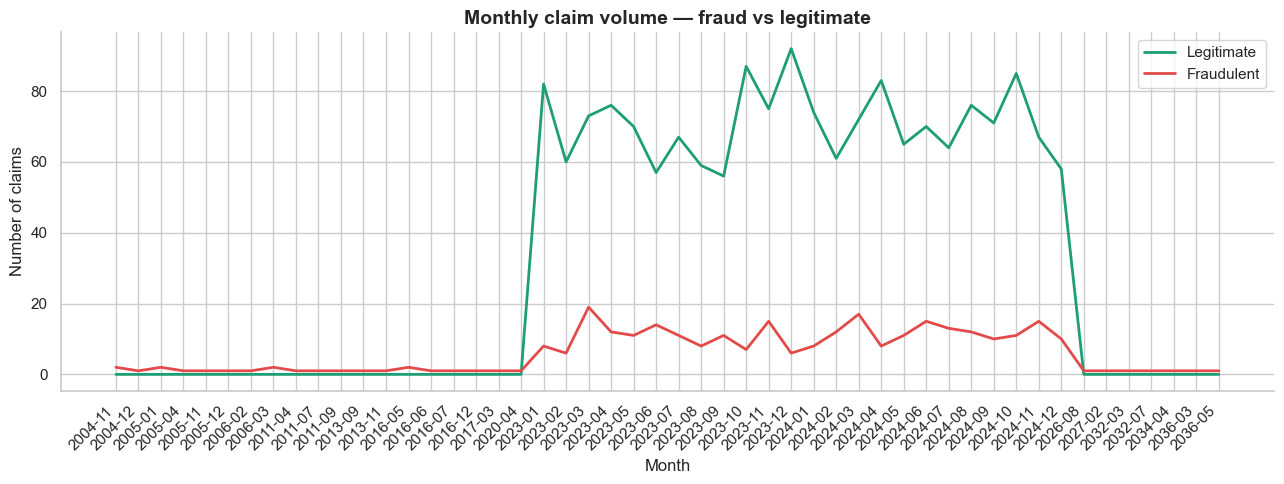

Peak fraud month: 2023-03 (19 claims)
Peak legit month: 2023-12 (92 claims)


In [26]:
claims['month'] = claims['claim_date'].dt.to_period('M')

monthly = claims.groupby(['month', 'is_fraud']).size().unstack(fill_value=0)
monthly.columns = ['Legitimate', 'Fraudulent']
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly.index, monthly['Legitimate'], color='#1D9E75', linewidth=2, label='Legitimate')
ax.plot(monthly.index, monthly['Fraudulent'], color='#E24B4A', linewidth=2, label='Fraudulent')
ax.set_xlabel('Month')
ax.set_ylabel('Number of claims')
ax.set_title('Monthly claim volume — fraud vs legitimate', fontsize=14, fontweight='bold')
ax.legend()
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('chart5_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak fraud month: {monthly['Fraudulent'].idxmax()} ({monthly['Fraudulent'].max()} claims)")
print(f"Peak legit month: {monthly['Legitimate'].idxmax()} ({monthly['Legitimate'].max()} claims)")

## 6. Top 10 Highest Risk Providers
Which providers are responsible for the most fraud?

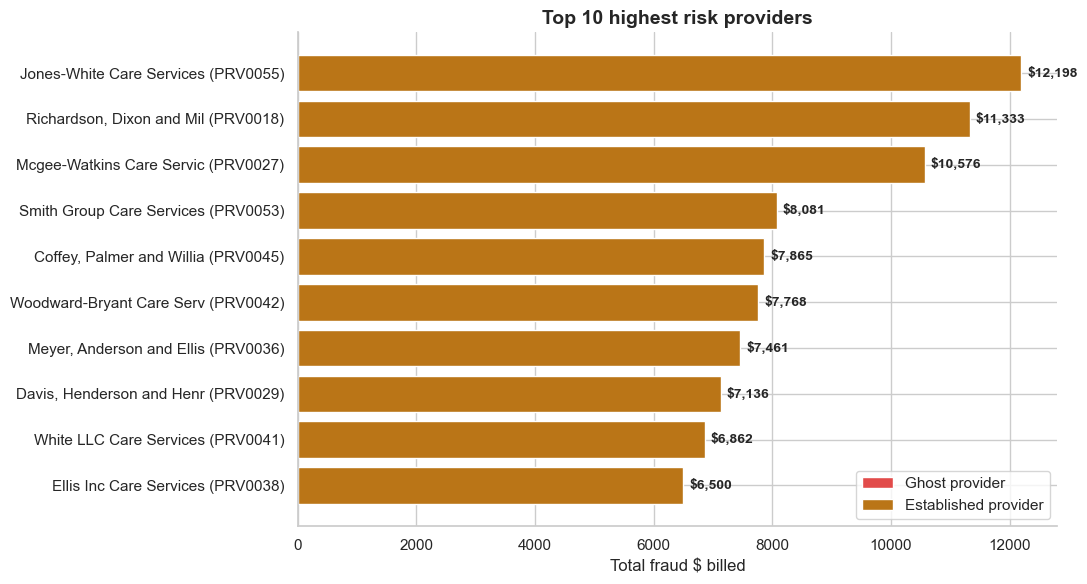

Top 10 riskiest providers:
────────────────────────────────────────────────────────────
PRV0055  $ 12,197.67  14 claims
PRV0018  $ 11,333.40  9 claims
PRV0027  $ 10,575.50  8 claims
PRV0053  $  8,080.80  8 claims
PRV0045  $  7,864.96  8 claims
PRV0042  $  7,767.54  8 claims
PRV0036  $  7,461.35  5 claims
PRV0029  $  7,136.37  6 claims
PRV0041  $  6,862.11  7 claims
PRV0038  $  6,500.00  4 claims


In [30]:
provider_fraud = claims[claims['is_fraud']==True].groupby('provider_id').agg(
    fraud_claims=('claim_id','count'),
    fraud_dollars=('billed_amount','sum')
).reset_index().sort_values('fraud_dollars', ascending=True).tail(10)

provider_fraud = provider_fraud.merge(providers[['provider_id','provider_name','is_ghost_provider']], on='provider_id')
provider_fraud['label'] = provider_fraud['provider_name'].str[:25] + ' (' + provider_fraud['provider_id'] + ')'
colors = ['#E24B4A' if g else '#BA7517' for g in provider_fraud['is_ghost_provider']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(provider_fraud['label'], provider_fraud['fraud_dollars'], color=colors)
ax.set_xlabel('Total fraud $ billed')
ax.set_title('Top 10 highest risk providers', fontsize=14, fontweight='bold')
for i, v in enumerate(provider_fraud['fraud_dollars']):
    ax.text(v + 100, i, f'${v:,.0f}', va='center', fontweight='bold', fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E24B4A', label='Ghost provider'),
                   Patch(facecolor='#BA7517', label='Established provider')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('chart6_top_providers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 riskiest providers:")
print("─" * 60)
for _, row in provider_fraud.sort_values('fraud_dollars', ascending=False).iterrows():
    ghost = " ← GHOST" if row['is_ghost_provider'] else ""
    print(f"{row['provider_id']}  ${row['fraud_dollars']:>10,.2f}  {int(row['fraud_claims'])} claims{ghost}")

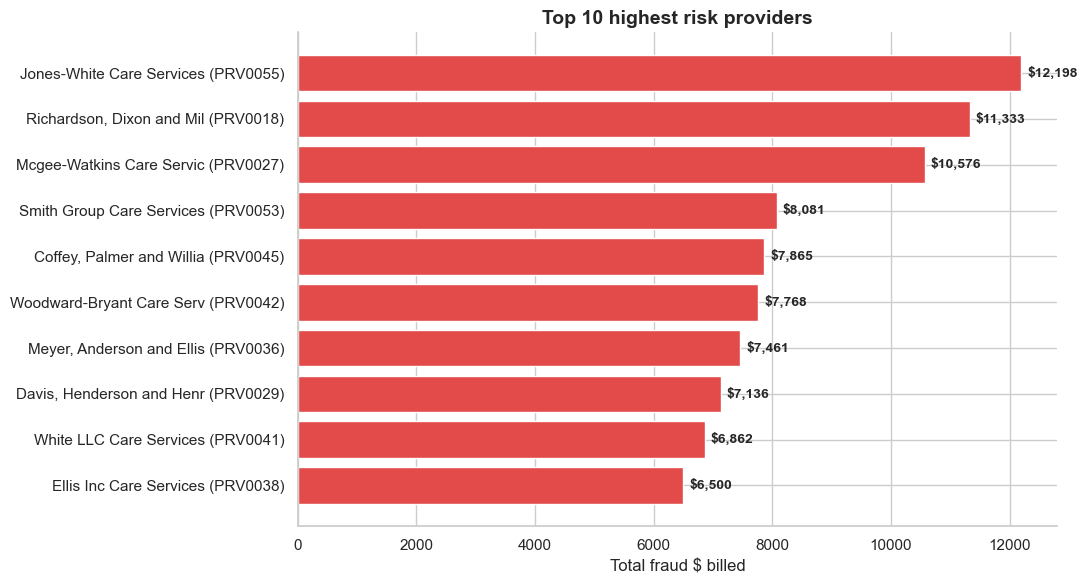

Top 10 riskiest providers:
────────────────────────────────────────────────────────────
PRV0055  $ 12,197.67  14 claims
PRV0018  $ 11,333.40  9 claims
PRV0027  $ 10,575.50  8 claims
PRV0053  $  8,080.80  8 claims
PRV0045  $  7,864.96  8 claims
PRV0042  $  7,767.54  8 claims
PRV0036  $  7,461.35  5 claims
PRV0029  $  7,136.37  6 claims
PRV0041  $  6,862.11  7 claims
PRV0038  $  6,500.00  4 claims


In [37]:
provider_fraud = claims[claims['is_fraud']==True].groupby('provider_id').agg(
    fraud_claims=('claim_id','count'),
    fraud_dollars=('billed_amount','sum')
).reset_index().sort_values('fraud_dollars', ascending=True).tail(10)

provider_fraud = provider_fraud.merge(providers[['provider_id','provider_name','is_ghost_provider']], on='provider_id')
provider_fraud['label'] = provider_fraud['provider_name'].str[:25] + ' (' + provider_fraud['provider_id'] + ')'

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(provider_fraud['label'], provider_fraud['fraud_dollars'], color='#E24B4A')
ax.set_xlabel('Total fraud $ billed')
ax.set_title('Top 10 highest risk providers', fontsize=14, fontweight='bold')
for i, v in enumerate(provider_fraud['fraud_dollars']):
    ax.text(v + 100, i, f'${v:,.0f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('chart6_top_providers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 riskiest providers:")
print("─" * 60)
for _, row in provider_fraud.sort_values('fraud_dollars', ascending=False).iterrows():
    ghost = " ← GHOST" if row['is_ghost_provider'] else ""
    print(f"{row['provider_id']}  ${row['fraud_dollars']:>10,.2f}  {int(row['fraud_claims'])} claims{ghost}")